In [7]:
from google.colab import files
uploaded = files.upload()

Saving titles.csv to titles.csv


In [8]:
import pandas as pd

df = pd.read_csv("titles.csv")
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


<Axes: xlabel='type'>

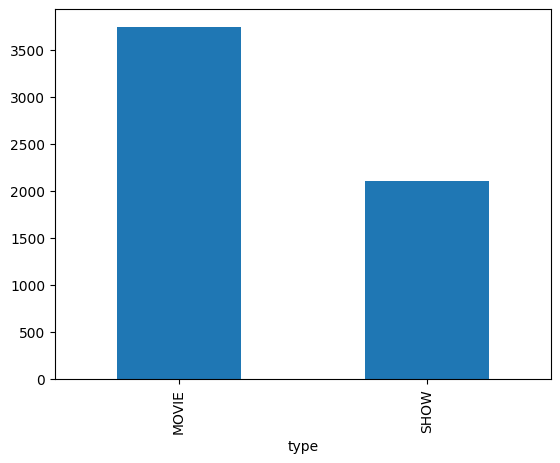

In [10]:
df['type'].value_counts().plot(kind='bar')

In [12]:
for col in df.columns:
    print(col)

id
title
type
description
release_year
age_certification
runtime
genres
production_countries
seasons
imdb_id
imdb_score
imdb_votes
tmdb_popularity
tmdb_score


Content Type Count:
 type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64


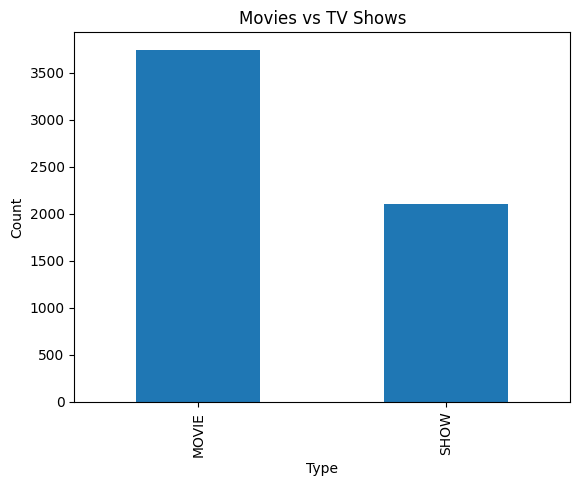


Top Countries:
 production_countries
US         2084
IN          610
GB          296
JP          273
Unknown     229
Name: count, dtype: int64


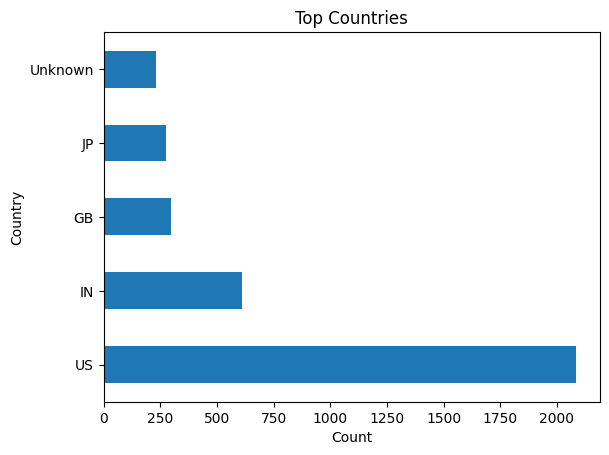


Top Genres:
 genres
drama            1421
comedy           1305
documentation     665
thriller          377
action            365
Name: count, dtype: int64


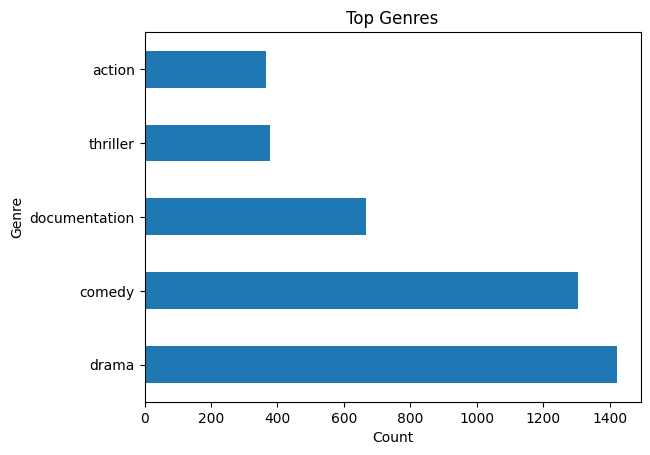

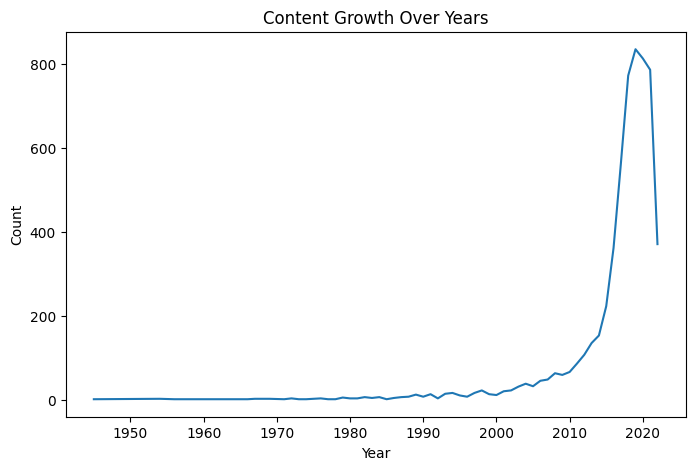

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

# Load dataset
df = pd.read_csv("titles.csv")

# CLEANING

# Convert column names to lowercase
df.columns = df.columns.str.strip().str.lower()

# Fix production_countries (convert string list - single value)
df['production_countries'] = df['production_countries'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else []
)
df['production_countries'] = df['production_countries'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

# Fix genres
df['genres'] = df['genres'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else []
)
df['genres'] = df['genres'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

#ANALYSIS


# Movies vs TV Shows
print("Content Type Count:\n", df['type'].value_counts())

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# Top Countries
print("\nTop Countries:\n", df['production_countries'].value_counts().head())

df['production_countries'].value_counts().head().plot(kind='barh')
plt.title("Top Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

#Top Genres
print("\nTop Genres:\n", df['genres'].value_counts().head())

df['genres'].value_counts().head().plot(kind='barh')
plt.title("Top Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

#Content Growth Over Years
df['release_year'].value_counts().sort_index().plot(figsize=(8,5))
plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()